In [4]:
try:
    %pip install --user "oracledb" --no-warn-script-location
except Exception as e:
    print("\x1b[31m\u2717 Unexpected error! Please contact course staff\n" +
         "Please include the entire text above and below in your message.")
    raise

Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

In [20]:
import oracledb

#Make sure to put in your user and password before running rest of code!
dsn = oracledb.makedsn("localhost", 1522, service_name="stu")
connection = oracledb.connect(
    user="ora_arthur0z",
    password="a80592421",
    dsn=dsn
)

cur = connection.cursor()

DatabaseError: ORA-02391: exceeded simultaneous SESSIONS_PER_USER limit
Help: https://docs.oracle.com/error-help/db/ora-02391/

In [21]:
cur.execute("""
    SELECT DISTINCT m.movie_id, r.tomatoMeter, r.audienceScore
    FROM movies m
    JOIN movie_metrics r ON m.movie_id = r.movie_id
    JOIN oscar_nominations o ON m.movie_id = o.movie_id
""")
nominated_scores = cur.fetchall()

cur.execute("""
    SELECT DISTINCT m.movie_id, r.tomatoMeter, r.audienceScore
    FROM movies m
    JOIN movie_metrics r ON m.movie_id = r.movie_id
    WHERE m.movie_id NOT IN (SELECT movie_id FROM oscar_nominations)
""")
not_nominated_scores = cur.fetchall()

In [22]:
nom_df = pd.DataFrame(nominated_scores, columns=['movie_id', 'Critic_Score', 'Audience_Score'])
not_nom_df = pd.DataFrame(not_nominated_scores, columns=['movie_id', 'Critic_Score', 'Audience_Score'])

critic_stat, critic_p = ttest_ind(nom_df['Critic_Score'], not_nom_df['Critic_Score'], equal_var=False)
aud_stat, aud_p = ttest_ind(nom_df['Audience_Score'], not_nom_df['Audience_Score'], equal_var=False)

print(f"Critic Score Difference   -> T-statistic: {critic_stat:.4f}, P-value: {critic_p:.4e}")
print(f"Audience Score Difference -> T-statistic: {aud_stat:.4f}, P-value: {aud_p:.4e}")

NameError: name 'ttest_ind' is not defined

/tmp/ipykernel_233/1350000800.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([nom_df['Audience_Score'], not_nom_df['Audience_Score']], labels=['Nominated', 'Not Nominated'])


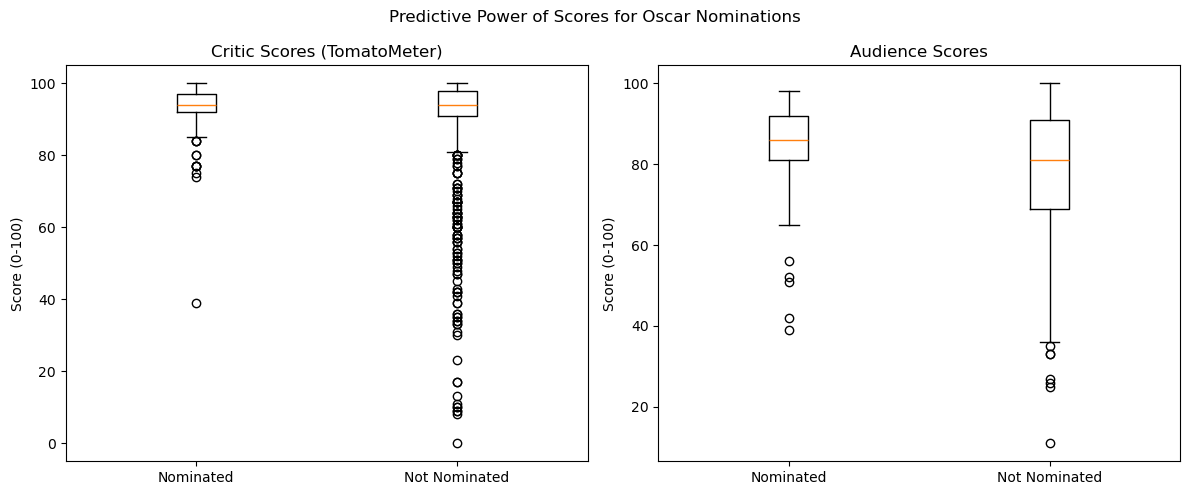

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Critic Scores
ax1.boxplot([nom_df['Critic_Score'], not_nom_df['Critic_Score']], tick_labels=['Nominated', 'Not Nominated'])
ax1.set_title('Critic Scores (TomatoMeter)')
ax1.set_ylabel('Score (0-100)')

# Plot 2: Audience Scores
ax2.boxplot([nom_df['Audience_Score'], not_nom_df['Audience_Score']], tick_labels=['Nominated', 'Not Nominated'])
ax2.set_title('Audience Scores')
ax2.set_ylabel('Score (0-100)')

plt.suptitle('Predictive Power of Scores for Oscar Nominations')
plt.tight_layout()
plt.show()

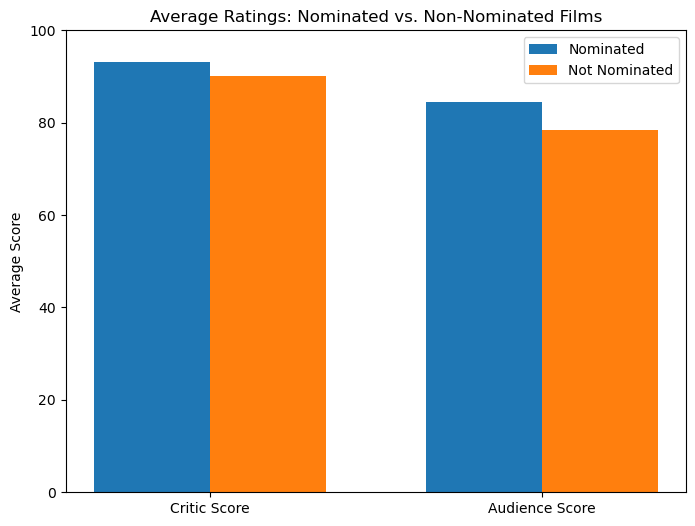

In [10]:
avg_nom_critic = nom_df['Critic_Score'].mean()
avg_not_nom_critic = not_nom_df['Critic_Score'].mean()

avg_nom_aud = nom_df['Audience_Score'].mean()
avg_not_nom_aud = not_nom_df['Audience_Score'].mean()

labels = ['Critic Score', 'Audience Score']
nominated_means = [avg_nom_critic, avg_nom_aud]
not_nominated_means = [avg_not_nom_critic, avg_not_nom_aud]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, nominated_means, width, label='Nominated')
rects2 = ax.bar(x + width/2, not_nominated_means, width, label='Not Nominated')

ax.set_ylabel('Average Score')
ax.set_title('Average Ratings: Nominated vs. Non-Nominated Films')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 100)

plt.show()

In [11]:
# Query 3
cur.execute("""
    SELECT year_ceremony AS year, COUNT(DISTINCT o.nomination_id) AS foreign_nomination_count 
    FROM oscar_nominations o JOIN movies m ON o.movie_id = m.movie_id 
    WHERE m.language != 'English' AND o.canon_category != 'BEST INTERNATIONAL FEATURE FILM' AND o.year_ceremony < 2020
    GROUP BY year_ceremony
""")

pre_2020 = cur.fetchall()

cur.execute("""
    SELECT year_ceremony AS year, COUNT(DISTINCT o.nomination_id) AS foreign_nomination_count 
    FROM oscar_nominations o JOIN movies m ON o.movie_id = m.movie_id 
    WHERE m.language != 'English' AND o.canon_category != 'BEST INTERNATIONAL FEATURE FILM' AND o.year_ceremony >= 2020
    GROUP BY year_ceremony
""")

post_2020 = cur.fetchall()

In [12]:
pre_2020_df = pd.DataFrame(pre_2020)
post_2020_df = pd.DataFrame(post_2020)

pre_2020_df = pre_2020_df.rename(columns={0: 'Year', 1: 'Nominations'})
post_2020_df = post_2020_df.rename(columns={0: 'Year', 1: 'Nominations'})

u_statistic, p_value = mannwhitneyu(pre_2020_df['Nominations'], post_2020_df['Nominations'], alternative='two-sided')
print(f"U-statistic: {u_statistic}")
print(f"P-value: {p_value}")

U-statistic: 6.0
P-value: 0.6631172453203822


In [13]:
foreign_noms = pd.concat([pre_2020_df, post_2020_df], ignore_index=True)
print(foreign_noms)

   Year  Nominations
0  2019           18
1  2017            9
2  2016            6
3  2018            4
4  2021            8
5  2022           14
6  2023            7
7  2020           14


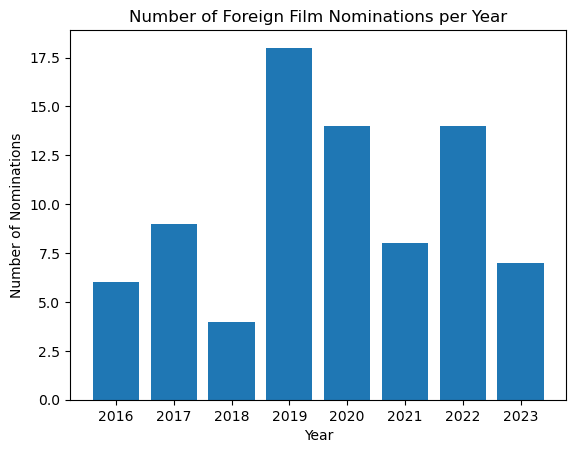

In [18]:
plt.bar(foreign_noms['Year'], foreign_noms['Nominations'])
plt.title('Number of Foreign Film Nominations per Year')
plt.xlabel('Year')
plt.ylabel('Number of Nominations')
plt.show()

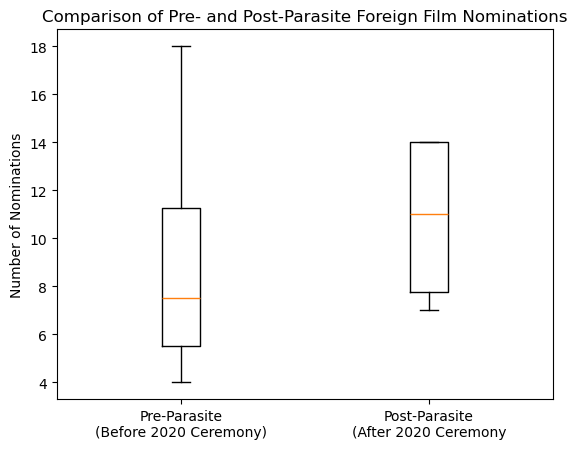

In [17]:
boxplot_data = [pre_2020_df['Nominations'], post_2020_df['Nominations']]
plt.boxplot(boxplot_data, tick_labels = ['Pre-Parasite\n(Before 2020 Ceremony)','Post-Parasite\n(After 2020 Ceremony'])
plt.title('Comparison of Pre- and Post-Parasite Foreign Film Nominations')
plt.ylabel('Number of Nominations')
plt.show()